# Day 1

## Stage 1 — Odds collection & vig removal
Pulls live NBA odds from The Odds API, strips the vig,
and computes consensus probabilities across all bookmakers.

In [7]:
!pip install requests

Importing and API setup

In [8]:
import requests
import pandas as pd
import json

API_KEY = "de954158190d8ddae5003a0584edf0b0"

response = requests.get(
    "https://api.the-odds-api.com/v4/sports/basketball_nba/odds",
    params={
        "apiKey": API_KEY,
        "regions": "us",
        "markets": "h2h",  # head to head (home / draw / away)
        "oddsFormat": "decimal"
    }
)

data = response.json()
print(json.dumps(data, indent=4))

[
    {
        "id": "61b1ef0450e08478d708e8ab8a384647",
        "sport_key": "basketball_nba",
        "sport_title": "NBA",
        "commence_time": "2026-03-28T19:10:00Z",
        "home_team": "Milwaukee Bucks",
        "away_team": "San Antonio Spurs",
        "bookmakers": [
            {
                "key": "fanduel",
                "title": "FanDuel",
                "last_update": "2026-03-28T15:50:28Z",
                "markets": [
                    {
                        "key": "h2h",
                        "last_update": "2026-03-28T15:50:28Z",
                        "outcomes": [
                            {
                                "name": "Milwaukee Bucks",
                                "price": 12.0
                            },
                            {
                                "name": "San Antonio Spurs",
                                "price": 1.05
                            }
                        ]
                    }
        

In [9]:
print(f"{len(data)} games found")

7 games found


Game 1

In [10]:
game = data[0]
print(game["home_team"], "vs", game["away_team"])
print("Date:", game["commence_time"])

Milwaukee Bucks vs San Antonio Spurs
Date: 2026-03-28T19:10:00Z


In [11]:
for i in range(len(game["bookmakers"])):
  book = game["bookmakers"][i]
  print(f"\nBookmaker: {book['title']}")
  for outcome in book["markets"][0]["outcomes"]:
      implied_prob = 1 / outcome["price"]
      print(f"  {outcome['name']}: {outcome['price']} odds = {implied_prob:.1%}")


Bookmaker: FanDuel
  Milwaukee Bucks: 12.0 odds = 8.3%
  San Antonio Spurs: 1.05 odds = 95.2%

Bookmaker: MyBookie.ag
  Milwaukee Bucks: 11.13 odds = 9.0%
  San Antonio Spurs: 1.04 odds = 96.2%

Bookmaker: DraftKings
  Milwaukee Bucks: 12.0 odds = 8.3%
  San Antonio Spurs: 1.05 odds = 95.2%

Bookmaker: BetRivers
  Milwaukee Bucks: 11.0 odds = 9.1%
  San Antonio Spurs: 1.04 odds = 96.2%

Bookmaker: LowVig.ag
  Milwaukee Bucks: 12.2 odds = 8.2%
  San Antonio Spurs: 1.05 odds = 95.2%

Bookmaker: BetOnline.ag
  Milwaukee Bucks: 11.69 odds = 8.6%
  San Antonio Spurs: 1.05 odds = 95.2%

Bookmaker: BetMGM
  Milwaukee Bucks: 12.5 odds = 8.0%
  San Antonio Spurs: 1.04 odds = 96.2%

Bookmaker: Bovada
  Milwaukee Bucks: 10.5 odds = 9.5%
  San Antonio Spurs: 1.05 odds = 95.2%

Bookmaker: BetUS
  Milwaukee Bucks: 11.75 odds = 8.5%
  San Antonio Spurs: 1.05 odds = 95.2%


Strip out the vig (bookmaker's built-in profit margin) and normalise the probabilities

In [12]:
def normalize_odds(bookmaker):
    outcomes = bookmaker["markets"][0]["outcomes"]

    # raw implied probabilities
    raw_probs = {o["name"]: 1 / o["price"] for o in outcomes}

    # total adds up to > 1 because of vig
    total = sum(raw_probs.values())
    vig = (total - 1) * 100

    # normalize so they sum to exactly 100%
    clean_probs = {name: prob / total for name, prob in raw_probs.items()}

    return clean_probs, vig

# ------------------------------------------------------------------------

# Run it across all bookmakers
for book in game["bookmakers"]:
    probs, vig = normalize_odds(book)
    print(f"\n{book['title']} (vig: {vig:.1f}%)")
    for team, prob in probs.items():
        print(f"  {team}: {prob:.1%}")


FanDuel (vig: 3.6%)
  Milwaukee Bucks: 8.0%
  San Antonio Spurs: 92.0%

MyBookie.ag (vig: 5.1%)
  Milwaukee Bucks: 8.5%
  San Antonio Spurs: 91.5%

DraftKings (vig: 3.6%)
  Milwaukee Bucks: 8.0%
  San Antonio Spurs: 92.0%

BetRivers (vig: 5.2%)
  Milwaukee Bucks: 8.6%
  San Antonio Spurs: 91.4%

LowVig.ag (vig: 3.4%)
  Milwaukee Bucks: 7.9%
  San Antonio Spurs: 92.1%

BetOnline.ag (vig: 3.8%)
  Milwaukee Bucks: 8.2%
  San Antonio Spurs: 91.8%

BetMGM (vig: 4.2%)
  Milwaukee Bucks: 7.7%
  San Antonio Spurs: 92.3%

Bovada (vig: 4.8%)
  Milwaukee Bucks: 9.1%
  San Antonio Spurs: 90.9%

BetUS (vig: 3.7%)
  Milwaukee Bucks: 8.2%
  San Antonio Spurs: 91.8%


Finding market average

In [13]:
from collections import defaultdict

team_probs = defaultdict(list)

for book in game["bookmakers"]:
    probs, _ = normalize_odds(book)
    for team, prob in probs.items():
        team_probs[team].append(prob)

print("Consensus probabilities (market average):")
for team, probs in team_probs.items():
    consensus = sum(probs) / len(probs)
    print(f"  {team}: {consensus:.1%}  (range: {min(probs):.1%} – {max(probs):.1%})")

Consensus probabilities (market average):
  Milwaukee Bucks: 8.3%  (range: 7.7% – 9.1%)
  San Antonio Spurs: 91.7%  (range: 90.9% – 92.3%)


Going through all the games in our earlier data

In [14]:
rows = []

for game in data:
    team_probs = defaultdict(list)

    for book in game["bookmakers"]:
        probs, _ = normalize_odds(book)
        for team, prob in probs.items():
            team_probs[team].append(prob)

    teams = list(team_probs.keys())

    for team in teams:
        probs = team_probs[team]
        rows.append({
            "game": f"{game['home_team']} vs {game['away_team']}",
            "team": team,
            "consensus_prob": sum(probs) / len(probs),
            "min_prob": min(probs),
            "max_prob": max(probs),
            "spread": max(probs) - min(probs),
            "num_books": len(probs),
            "commence_time": game["commence_time"]
        })

df = pd.DataFrame(rows)
df = df.sort_values("spread", ascending=False)
print(df.to_string(index=False))

                                     game                   team  consensus_prob  min_prob  max_prob   spread  num_books        commence_time
       Memphis Grizzlies vs Chicago Bulls          Chicago Bulls        0.612778  0.602532  0.620438 0.017906          9 2026-03-29T00:10:00Z
       Memphis Grizzlies vs Chicago Bulls      Memphis Grizzlies        0.387222  0.379562  0.397468 0.017906          9 2026-03-29T00:10:00Z
 Oklahoma City Thunder vs New York Knicks  Oklahoma City Thunder        0.750248  0.741483  0.759013 0.017530          2 2026-03-29T23:40:00Z
 Oklahoma City Thunder vs New York Knicks        New York Knicks        0.249752  0.240987  0.258517 0.017530          2 2026-03-29T23:40:00Z
        Atlanta Hawks vs Sacramento Kings          Atlanta Hawks        0.872435  0.863132  0.880088 0.016956          9 2026-03-28T23:40:00Z
        Atlanta Hawks vs Sacramento Kings       Sacramento Kings        0.127565  0.119912  0.136868 0.016956          9 2026-03-28T23:40:00Z
Minnes

Visualising

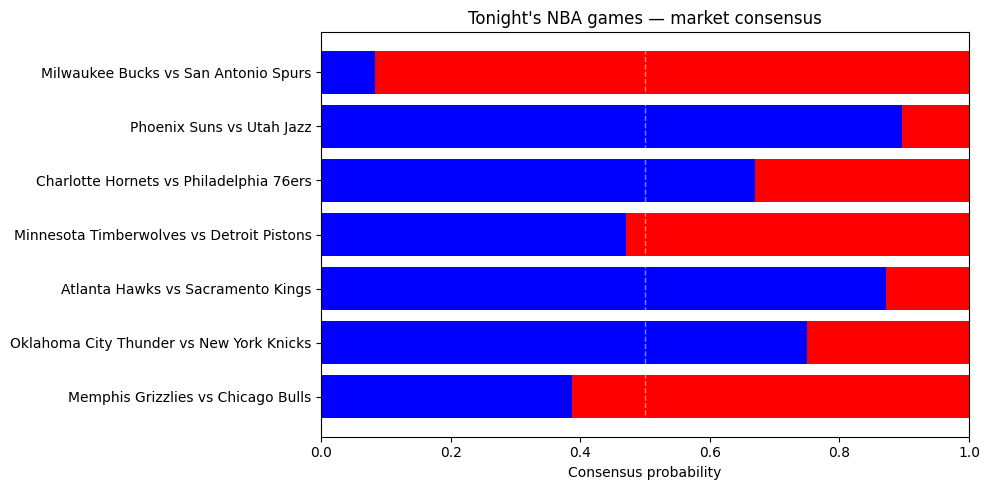

In [15]:
import matplotlib.pyplot as plt

# filter to games with more than 1 book
df_reliable = df[df["num_books"] > 1].copy()

# keep just one row per game (home team)
home_teams = df_reliable[df_reliable.apply(
    lambda r: r["team"] == r["game"].split(" vs ")[0], axis=1
)]

fig, ax = plt.subplots(figsize=(10, 5))

for _, row in home_teams.iterrows():
    away_team = df_reliable[
        (df_reliable["game"] == row["game"]) &
        (df_reliable["team"] != row["team"])
    ].iloc[0]

    label = f"{row['team']} vs {away_team['team']}"
    ax.barh(label, row["consensus_prob"], color="blue", label="Home")
    ax.barh(label, away_team["consensus_prob"],
            left=row["consensus_prob"], color="red")

ax.axvline(0.5, color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Consensus probability")
ax.set_title("Tonight's NBA games — market consensus")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Making the graph better

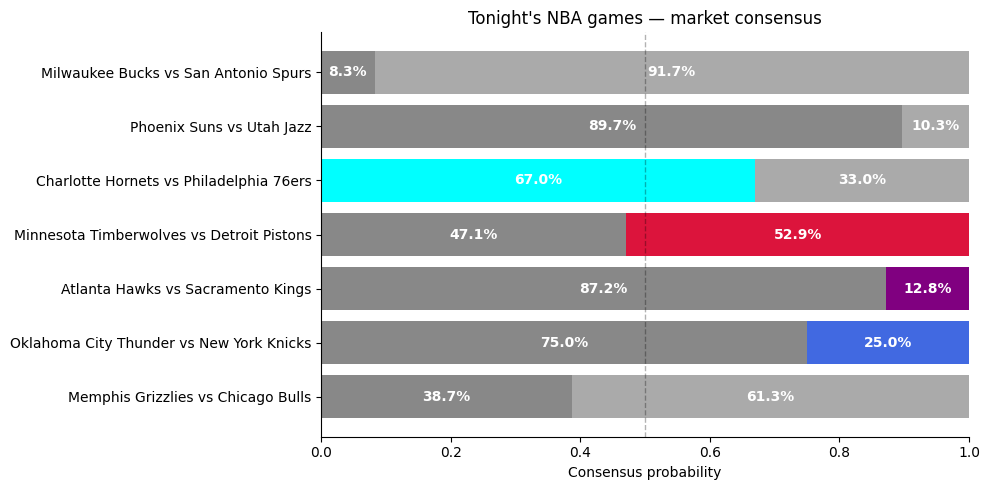

In [16]:
TEAM_COLORS = {
    "Charlotte Hornets": "cyan",
    "New York Knicks": "royalblue",
    "Detroit Pistons": "crimson",
    "New Orleans Pelicans": "navy",
    "Orlando Magic": "dodgerblue",
    "Sacramento Kings": "purple",
}

fig, ax = plt.subplots(figsize=(10, 5))

for _, row in home_teams.iterrows():
    away = df_reliable[
        (df_reliable["game"] == row["game"]) &
        (df_reliable["team"] != row["team"])
    ].iloc[0]

    home_color = TEAM_COLORS.get(row["team"], "#888888")
    away_color = TEAM_COLORS.get(away["team"], "#aaaaaa")
    label = f"{row['team']} vs {away['team']}"

    ax.barh(label, row["consensus_prob"], color=home_color)
    ax.barh(label, away["consensus_prob"], left=row["consensus_prob"], color=away_color)

    # probability labels inside bars
    ax.text(row["consensus_prob"] / 2, label,
            f"{row['consensus_prob']:.1%}", va="center", ha="center",
            color="white", fontsize=10, fontweight="bold")
    ax.text(row["consensus_prob"] + away["consensus_prob"] / 2, label,
            f"{away['consensus_prob']:.1%}", va="center", ha="center",
            color="white", fontsize=10, fontweight="bold")

ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.3)
ax.set_xlabel("Consensus probability")
ax.set_title("Tonight's NBA games — market consensus")
ax.set_xlim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Stage 2 — Historical data & team stats

NBA Standings data

In [17]:
import pandas as pd

url = "https://www.basketball-reference.com/leagues/NBA_2026_standings.html"
tables = pd.read_html(url)

# eastern and western conference standings
east = tables[0]
west = tables[1]

print("Eastern Conference:")
print(east[["Eastern Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].head(10))
print("\nWestern Conference:")
print(west[["Western Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].head(10))

Eastern Conference:
        Eastern Conference   W   L   W/L%   PS/G   PA/G
0     Detroit Pistons* (1)  53  20  0.726  117.6  109.8
1       Boston Celtics (2)  49  24  0.671  114.1  106.9
2      New York Knicks (3)  48  26  0.649  117.0  110.5
3  Cleveland Cavaliers (4)  46  28  0.622  119.4  115.2
4      Toronto Raptors (5)  41  32  0.562  114.0  112.3
5        Atlanta Hawks (6)  41  33  0.554  118.2  116.5
6   Philadelphia 76ers (7)  40  33  0.548  116.2  116.5
7    Charlotte Hornets (8)  39  34  0.534  116.3  111.6
8        Orlando Magic (9)  39  34  0.534  115.7  114.8
9          Miami Heat (10)  39  35  0.527  120.3  117.7

Western Conference:
           Western Conference   W   L   W/L%   PS/G   PA/G
0  Oklahoma City Thunder* (1)  58  16  0.784  118.8  107.7
1      San Antonio Spurs* (2)  55  18  0.753  119.3  111.5
2      Los Angeles Lakers (3)  48  26  0.649  116.6  114.9
3          Denver Nuggets (4)  47  28  0.627  121.3  116.9
4  Minnesota Timberwolves (5)  45  28  0.616  11

Combining conferences

In [18]:
import re

def clean_team_name(name):
    return re.sub(r"\s*\(\d+\)", "", name).strip()

east = east[["Eastern Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].copy()
west = west[["Western Conference", "W", "L", "W/L%", "PS/G", "PA/G"]].copy()

east.columns = ["team", "W", "L", "win_pct", "pts_scored", "pts_allowed"]
west.columns = ["team", "W", "L", "win_pct", "pts_scored", "pts_allowed"]

east["conference"] = "East"
west["conference"] = "West"

standings = pd.concat([east, west], ignore_index=True)
standings["team"] = standings["team"].apply(clean_team_name)

# add a simple net rating (offensive - defensive strength)
standings["net_pts"] = standings["pts_scored"] - standings["pts_allowed"]

print(standings[["team", "win_pct", "pts_scored", "pts_allowed", "net_pts"]]
      .sort_values("net_pts", ascending=False)
      .to_string(index=False))

                  team  win_pct  pts_scored  pts_allowed  net_pts
Oklahoma City Thunder*    0.784       118.8        107.7     11.1
      Detroit Pistons*    0.726       117.6        109.8      7.8
    San Antonio Spurs*    0.753       119.3        111.5      7.8
        Boston Celtics    0.671       114.1        106.9      7.2
       New York Knicks    0.649       117.0        110.5      6.5
     Charlotte Hornets    0.534       116.3        111.6      4.7
        Denver Nuggets    0.627       121.3        116.9      4.4
   Cleveland Cavaliers    0.622       119.4        115.2      4.2
Minnesota Timberwolves    0.616       118.3        114.4      3.9
       Houston Rockets    0.603       114.1        110.2      3.9
            Miami Heat    0.527       120.3        117.7      2.6
         Atlanta Hawks    0.554       118.2        116.5      1.7
       Toronto Raptors    0.562       114.0        112.3      1.7
    Los Angeles Lakers    0.649       116.6        114.9      1.7
  Los Ange

### (v1) Initial Prediction Model

When two teams play, the one with the better net rating should win more often.

Using the difference in net points between teams to estimate win probability

In [41]:
from scipy.special import expit  # sigmoid function

# Typically, home team is preferred by 2.5 - 3.5 points if 2 equal teams are playing
def predict_win_prob(home_team, away_team, standings, home_advantage=3.0):
    home = standings[standings["team"] == home_team].iloc[0]
    away = standings[standings["team"] == away_team].iloc[0]

    # difference in net rating + home court advantage
    diff = (home["net_pts"] - away["net_pts"]) + home_advantage

    # convert to probability using sigmoid
    # scaling factor 0.15 maps point diff to a reasonable probability range
    prob_home = expit(diff * 0.15)

    return {
        "home_team": home_team,
        "away_team": away_team,
        "model_home_prob": prob_home,
        "model_away_prob": 1 - prob_home
    }

# test on tonight's games
games = [
    ("Charlotte Hornets", "New York Knicks"),
    ("Detroit Pistons", "New Orleans Pelicans"),
    ("Orlando Magic", "Sacramento Kings"),
]

for home, away in games:
    pred = predict_win_prob(home, away, standings)
    print(f"\n{pred['home_team']} vs {pred['away_team']}")
    print(f"  Model:  {pred['home_team']} {pred['model_home_prob']:.1%} | {pred['away_team']} {pred['model_away_prob']:.1%}")


Charlotte Hornets vs New York Knicks
  Model:  Charlotte Hornets 53.7% | New York Knicks 46.3%

Detroit Pistons vs New Orleans Pelicans
  Model:  Detroit Pistons 90.5% | New Orleans Pelicans 9.5%

Orlando Magic vs Sacramento Kings
  Model:  Orlando Magic 89.1% | Sacramento Kings 10.9%


Comparing with market consensus

In [42]:
# pull consensus probs for tonight's games into a lookup
consensus_lookup = {}
for _, row in df_reliable.iterrows():
    consensus_lookup[(row["game"], row["team"])] = row["consensus_prob"]

print(f"{'Game':<45} {'Team':<25} {'Model':>8} {'Market':>8} {'Edge':>8}")
print("-" * 100)

for home, away in games:
    pred = predict_win_prob(home, away, standings)
    game_key = f"{home} vs {away}"

    for team, model_prob in [(home, pred["model_home_prob"]), (away, pred["model_away_prob"])]:
        market_prob = consensus_lookup.get((game_key, team), None)
        if market_prob:
            edge = model_prob - market_prob
            edge_str = f"+{edge:.1%}" if edge > 0 else f"{edge:.1%}"
            print(f"{game_key:<45} {team:<25} {model_prob:>7.1%} {market_prob:>7.1%} {edge_str:>8}")

Game                                          Team                         Model   Market     Edge
----------------------------------------------------------------------------------------------------


Orlando vs Sacramento is almost perfect agreement — both your model and the market see it as roughly 89/11. That's a good sign

Charlotte vs Knicks is a small +2.3% edge for Charlotte — our model is slightly more bullish on the home team than the market, likely because of home advantage combined with similar net ratings

But Detroit at +25.1% is the loud signal here. Our model thinks Detroit should be ~90% favorites, but the market only has them at 64.7%.

That's a massive gap and almost certainly means something our model doesn't know about — most likely injuries or rest.

The market prices in real-time information; our model only knows season-long averages.

### Adding an injury context check

In [43]:
# check what the market is implying vs our model
# a huge gap usually means missing context

for home, away in games:
    pred = predict_win_prob(home, away, standings)
    game_key = f"{home} vs {away}"

    home_market = consensus_lookup.get((game_key, home))
    model_home = pred["model_home_prob"]
    gap = abs(model_home - home_market)

    if gap > 0.10:
        print(f"Large gap detected: {game_key}")
        print(f"Model: {model_home:.1%} | Market: {home_market:.1%} | Gap: {gap:.1%}")
        print(f"Check injuries/rest for both teams before trusting this edge\n")

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

### Key limitation discovered
Model uses season averages only — does not account for:
- Injuries / player availability
- Back-to-back fatigue
- Recent form vs season-long averages

Large gaps between model and market (>15%) almost always
indicate missing context, not genuine betting edge.

Replacing season-long averages with recent form (last 10 games)

In [44]:
def get_recent_form(team_slug, season=2026, n_games=10):
    url = f"https://www.basketball-reference.com/teams/{team_slug}/{season}/gamelog"
    tables = pd.read_html(url)

    gl = tables[0]

    # flatten multi-index columns
    if isinstance(gl.columns, pd.MultiIndex):
        gl.columns = [' '.join(col).strip() for col in gl.columns]

    # filter to real games only
    gl = gl[gl["Unnamed: 0_level_0 Rk"].apply(lambda x: str(x).isdigit())].copy()

    gl["pts_scored"] = pd.to_numeric(gl["Score Tm"], errors="coerce")
    gl["pts_allowed"] = pd.to_numeric(gl["Score Opp"], errors="coerce")
    gl = gl.dropna(subset=["pts_scored", "pts_allowed"])

    recent = gl.tail(n_games)

    return {
        "pts_scored": recent["pts_scored"].mean(),
        "pts_allowed": recent["pts_allowed"].mean(),
        "net_pts": (recent["pts_scored"] - recent["pts_allowed"]).mean()
    }

In [45]:
TEAM_SLUGS = {
    "Charlotte Hornets": "CHO",
    "New York Knicks": "NYK",
    "Detroit Pistons": "DET",
    "New Orleans Pelicans": "NOP",
    "Orlando Magic": "ORL",
    "Sacramento Kings": "SAC",
    "Boston Celtics": "BOS",
    "Cleveland Cavaliers": "CLE",
    "Oklahoma City Thunder": "OKC",
    "San Antonio Spurs": "SAS",
    "Los Angeles Lakers": "LAL",
    "Denver Nuggets": "DEN",
    "Minnesota Timberwolves": "MIN",
    "Houston Rockets": "HOU",
    "Phoenix Suns": "PHO",
    "Los Angeles Clippers": "LAC",
    "Portland Trail Blazers": "POR",
    "Golden State Warriors": "GSW",
    "Philadelphia 76ers": "PHI",
    "Atlanta Hawks": "ATL",
    "Miami Heat": "MIA",
    "Toronto Raptors": "TOR",
    "Memphis Grizzlies": "MEM",
    "Chicago Bulls": "CHI",
    "Dallas Mavericks": "DAL",
    "Milwaukee Bucks": "MIL",
    "Utah Jazz": "UTA",
    "Indiana Pacers": "IND",
    "Brooklyn Nets": "BRK",
    "Washington Wizards": "WAS",
}

In [46]:
for home, away in games:
    for team in [home, away]:
        slug = TEAM_SLUGS[team]
        form = get_recent_form(slug)
        print(f"{team} (last 10): scored {form['pts_scored']:.1f} | allowed {form['pts_allowed']:.1f} | net {form['net_pts']:+.1f}")
    print()

Charlotte Hornets (last 10): scored 117.9 | allowed 107.5 | net +10.4
New York Knicks (last 10): scored 115.8 | allowed 109.7 | net +6.1

Detroit Pistons (last 10): scored 123.6 | allowed 109.9 | net +13.7
New Orleans Pelicans (last 10): scored 115.9 | allowed 113.5 | net +2.4

Orlando Magic (last 10): scored 119.8 | allowed 122.3 | net -2.5
Sacramento Kings (last 10): scored 113.8 | allowed 120.4 | net -6.6



### (v2) Improved prediction model

In [48]:
def predict_win_prob_v2(home_team, away_team, home_advantage=3.0):
    home_form = get_recent_form(TEAM_SLUGS[home_team])
    away_form = get_recent_form(TEAM_SLUGS[away_team])

    diff = (home_form["net_pts"] - away_form["net_pts"]) + home_advantage
    prob_home = expit(diff * 0.15)

    return {
        "home_team": home_team,
        "away_team": away_team,
        "model_v1": None,  # season average (filled below)
        "model_v2": prob_home,
        "model_v2_away": 1 - prob_home
    }

print(f"{'Game':<45} {'Team':<25} {'V1 (season)':>12} {'V2 (last 10)':>12} {'Market':>8} {'Edge':>8}")
print("-" * 115)

for home, away in games:
    v1 = predict_win_prob(home, away, standings)
    v2 = predict_win_prob_v2(home, away)
    game_key = f"{home} vs {away}"

    for team, v1_prob, v2_prob in [
        (home, v1["model_home_prob"], v2["model_v2"]),
        (away, v1["model_away_prob"], v2["model_v2_away"])
    ]:
        market = consensus_lookup.get((game_key, team))
        edge = v2_prob - market
        edge_str = f"+{edge:.1%}" if edge > 0 else f"{edge:.1%}"
        print(f"{game_key:<45} {team:<25} {v1_prob:>11.1%} {v2_prob:>11.1%} {market:>7.1%} {edge_str:>8}")
    print()

Game                                          Team                       V1 (season) V2 (last 10)   Market     Edge
-------------------------------------------------------------------------------------------------------------------


TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

### Model v2 limitations
- Recent form can be noisy over just 10 games
- Doesn't account for injuries (Murray/Murphy questionable tonight)
- Doesn't know opponent strength during that 10-game stretch
- A team can look good recently by playing weak opponents

---------------

Waiting for tonight's games and then comparing our models with the actual game outcomes.

---------------

# Day 2

Results:

Charlotte 114, Knicks 103

Detroit 129, Pelicans 108

Orlando 121, Kings 117

## Stage 3 — Backtesting & betting simulation
Simulate a full season of bets using model edges.
Track ROI, bankroll growth, and Kelly-sized stakes.

Pulling this season's NBA games

In [20]:
!pip install nba_api

In [21]:
from nba_api.stats.endpoints import leaguegamelog
import pandas as pd


def get_season_results():
    gamelog = leaguegamelog.LeagueGameLog(
        season="2025-26",
        season_type_all_star="Regular Season",
        player_or_team_abbreviation="T"
    )

    df = gamelog.get_data_frames()[0]
    df = df[["GAME_ID", "GAME_DATE", "TEAM_NAME", "MATCHUP", "WL", "PTS"]].copy()

    # split into home and away using GAME_ID to merge correctly
    home = df[df["MATCHUP"].str.contains("vs[.]")].copy()
    away = df[df["MATCHUP"].str.contains(" @ ")].copy()

    home = home[["GAME_ID", "GAME_DATE", "TEAM_NAME", "PTS", "WL"]]
    home.columns = ["game_id", "date", "home_team", "home_pts", "home_wl"]

    away = away[["GAME_ID", "TEAM_NAME", "PTS"]]
    away.columns = ["game_id", "away_team", "away_pts"]

    results = pd.merge(home, away, on="game_id")
    results["home_win"] = results["home_wl"] == "W"
    results = results[["date", "home_team", "away_team", "home_pts", "away_pts", "home_win"]]

    return results

print("Loading season results...")
results = get_season_results()
print(f"Total games loaded: {len(results)}")
print(results.head(10))

Loading season results...
Total games loaded: 1099
         date               home_team               away_team  home_pts  \
0  2025-10-21      Los Angeles Lakers   Golden State Warriors       109   
1  2025-10-21   Oklahoma City Thunder         Houston Rockets       125   
2  2025-10-22          Boston Celtics      Philadelphia 76ers       116   
3  2025-10-22           Chicago Bulls         Detroit Pistons       115   
4  2025-10-22         New York Knicks     Cleveland Cavaliers       119   
5  2025-10-22            Phoenix Suns        Sacramento Kings       120   
6  2025-10-22  Portland Trail Blazers  Minnesota Timberwolves       114   
7  2025-10-22       Memphis Grizzlies    New Orleans Pelicans       128   
8  2025-10-22           Atlanta Hawks         Toronto Raptors       118   
9  2025-10-22        Dallas Mavericks       San Antonio Spurs        92   

   away_pts  home_win  
0       119     False  
1       124      True  
2       117     False  
3       111      True  
4  

Backtesting framework for model v1

In [22]:
from scipy.special import expit

def backtest_season(results, standings, home_advantage=3.0):
    backtest_rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # look up standings for both teams
        home_stats = standings[standings["team"] == home]
        away_stats = standings[standings["team"] == away]

        # skip if team not found in standings
        if home_stats.empty or away_stats.empty:
            continue

        home_net = home_stats.iloc[0]["net_pts"]
        away_net = away_stats.iloc[0]["net_pts"]

        diff = (home_net - away_net) + home_advantage
        model_home_prob = expit(diff * 0.15)

        # did the model's favored team win?
        model_favors_home = model_home_prob > 0.5
        model_correct = (model_favors_home == game["home_win"])

        backtest_rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "model_home_prob": model_home_prob,
            "model_favors_home": model_favors_home,
            "actual_home_win": game["home_win"],
            "correct": model_correct
        })

    return pd.DataFrame(backtest_rows)

bt = backtest_season(results, standings)

total = len(bt)
correct = bt["correct"].sum()
accuracy = correct / total

print(f"Games evaluated: {total}")
print(f"Correct predictions: {correct}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Baseline (always pick home): {results['home_win'].mean():.1%}")

Games evaluated: 821
Correct predictions: 560
Accuracy: 68.2%
Baseline (always pick home): 54.9%


Data grabbing problem, we'll fix it by using nba api only

In [23]:
from nba_api.stats.endpoints import leaguestandings

standings_data = leaguestandings.LeagueStandings(season="2025-26")
df = standings_data.get_data_frames()[0]
print(df.columns.tolist())

['LeagueID', 'SeasonID', 'TeamID', 'TeamCity', 'TeamName', 'Conference', 'ConferenceRecord', 'PlayoffRank', 'ClinchIndicator', 'Division', 'DivisionRecord', 'DivisionRank', 'WINS', 'LOSSES', 'WinPCT', 'LeagueRank', 'Record', 'HOME', 'ROAD', 'L10', 'Last10Home', 'Last10Road', 'OT', 'ThreePTSOrLess', 'TenPTSOrMore', 'LongHomeStreak', 'strLongHomeStreak', 'LongRoadStreak', 'strLongRoadStreak', 'LongWinStreak', 'LongLossStreak', 'CurrentHomeStreak', 'strCurrentHomeStreak', 'CurrentRoadStreak', 'strCurrentRoadStreak', 'CurrentStreak', 'strCurrentStreak', 'ConferenceGamesBack', 'DivisionGamesBack', 'ClinchedConferenceTitle', 'ClinchedDivisionTitle', 'ClinchedPlayoffBirth', 'EliminatedConference', 'EliminatedDivision', 'AheadAtHalf', 'BehindAtHalf', 'TiedAtHalf', 'AheadAtThird', 'BehindAtThird', 'TiedAtThird', 'Score100PTS', 'OppScore100PTS', 'OppOver500', 'LeadInFGPCT', 'LeadInReb', 'FewerTurnovers', 'PointsPG', 'OppPointsPG', 'DiffPointsPG', 'vsEast', 'vsAtlantic', 'vsCentral', 'vsSoutheast

In [24]:
from nba_api.stats.endpoints import leaguestandings
import pandas as pd

def get_standings():
    standings_data = leaguestandings.LeagueStandings(season="2025-26")
    df = standings_data.get_data_frames()[0]

    # keep relevant columns
    df = df[["TeamName", "TeamCity", "WINS", "LOSSES", "WinPCT", "PointsPG", "OppPointsPG"]].copy()
    df.columns = ["team_name", "team_city", "W", "L", "win_pct", "pts_scored", "pts_allowed"]
    df["team"] = df["team_city"] + " " + df["team_name"]
    df["net_pts"] = df["pts_scored"] - df["pts_allowed"]

    return df[["team", "W", "L", "win_pct", "pts_scored", "pts_allowed", "net_pts"]]

standings = get_standings()
print(standings.sort_values("net_pts", ascending=False).to_string(index=False))

                  team  W  L  win_pct  pts_scored  pts_allowed  net_pts
 Oklahoma City Thunder 58 16    0.784       119.0        108.0     11.0
       Detroit Pistons 53 20    0.726       118.0        110.0      8.0
     San Antonio Spurs 55 18    0.753       119.0        111.0      8.0
        Boston Celtics 49 24    0.671       114.0        107.0      7.0
       New York Knicks 48 26    0.649       117.0        111.0      6.0
        Denver Nuggets 47 28    0.627       121.0        117.0      4.0
Minnesota Timberwolves 45 28    0.616       118.0        114.0      4.0
   Cleveland Cavaliers 46 28    0.622       119.0        115.0      4.0
       Houston Rockets 44 29    0.603       114.0        110.0      4.0
     Charlotte Hornets 39 34    0.534       116.0        112.0      4.0
       Toronto Raptors 41 32    0.562       114.0        112.0      2.0
         Atlanta Hawks 41 33    0.554       118.0        116.0      2.0
            Miami Heat 39 35    0.527       120.0        118.0  

Backtesting

In [25]:
from scipy.special import expit

def backtest_season(results, standings, home_advantage=3.0):
    backtest_rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # look up standings for both teams
        home_stats = standings[standings["team"] == home]
        away_stats = standings[standings["team"] == away]

        # skip if team not found in standings
        if home_stats.empty or away_stats.empty:
            continue

        home_net = home_stats.iloc[0]["net_pts"]
        away_net = away_stats.iloc[0]["net_pts"]

        diff = (home_net - away_net) + home_advantage
        model_home_prob = expit(diff * 0.15)

        # did the model's favored team win?
        model_favors_home = model_home_prob > 0.5
        model_correct = (model_favors_home == game["home_win"])

        backtest_rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "model_home_prob": model_home_prob,
            "model_favors_home": model_favors_home,
            "actual_home_win": game["home_win"],
            "correct": model_correct
        })

    return pd.DataFrame(backtest_rows)

bt = backtest_season(results, standings)

total = len(bt)
correct = bt["correct"].sum()
accuracy = correct / total

print(f"Games evaluated: {total}")
print(f"Correct predictions: {correct}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Baseline (always pick home): {results['home_win'].mean():.1%}")

Games evaluated: 1099
Correct predictions: 769
Accuracy: 70.0%
Baseline (always pick home): 54.9%


Adding Kelly Criterion Simulation

In [26]:
def kelly_fraction(model_prob, odds_decimal, fraction=0.25):
    # implied probability from bookmaker odds
    implied_prob = 1 / odds_decimal

    # edge = how much better our model is than the bookmaker
    edge = model_prob - implied_prob

    # kelly formula: edge / odds
    kelly = edge / (odds_decimal - 1)

    # use fractional kelly (0.25) to be conservative
    return max(0, kelly * fraction)

# simulate flat odds of 1.91 (standard -110 line) for all games
# we'll pull real odds per game in a later stage
SIMULATED_ODDS = 1.91
STARTING_BANKROLL = 1000
bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]

for _, game in bt.iterrows():
    home_prob = game["model_home_prob"]
    away_prob = 1 - home_prob

    # bet on whichever side the model favors
    if home_prob > 0.55:  # only bet when we have meaningful edge
        bet_prob = home_prob
        bet_wins = game["actual_home_win"]
    elif away_prob > 0.55:
        bet_prob = away_prob
        bet_wins = not game["actual_home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    stake = kelly_fraction(bet_prob, SIMULATED_ODDS) * bankroll

    if bet_wins:
        bankroll += stake * (SIMULATED_ODDS - 1)
    else:
        bankroll -= stake

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")
print(f"Bets placed:       {len(bankroll_history)-1}")

Starting bankroll: $1000.00
Final bankroll:    $146609765020542.56
ROI:               14660976501954.3%
Bets placed:       1099


### Bug found: look-ahead bias
Current backtest uses end-of-season standings for all predictions.
This leaks future information into past predictions and inflates results.

Fix: rebuild standings incrementally from game results,
so each prediction only uses data available before that game date.
This is called a rolling or point-in-time backtest.

In [27]:
def build_rolling_standings(results):
    # sort all games chronologically
    results = results.sort_values("date").copy()

    # track running stats per team
    stats = {}
    rolling_rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        # initialize teams if first appearance
        for team in [home, away]:
            if team not in stats:
                stats[team] = {"pts_scored": [], "pts_allowed": []}

        # record standings BEFORE this game (what we'd know at tip-off)
        rolling_rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "home_pts": game["home_pts"],
            "away_pts": game["away_pts"],
            "home_win": game["home_win"],
            "home_net": (sum(stats[home]["pts_scored"]) - sum(stats[home]["pts_allowed"])) / max(len(stats[home]["pts_scored"]), 1),
            "away_net": (sum(stats[away]["pts_scored"]) - sum(stats[away]["pts_allowed"])) / max(len(stats[away]["pts_scored"]), 1),
            "home_games_played": len(stats[home]["pts_scored"]),
            "away_games_played": len(stats[away]["pts_scored"])
        })

        # now update stats AFTER recording (so it's not used until next game)
        stats[home]["pts_scored"].append(game["home_pts"])
        stats[home]["pts_allowed"].append(game["away_pts"])
        stats[away]["pts_scored"].append(game["away_pts"])
        stats[away]["pts_allowed"].append(game["home_pts"])

    return pd.DataFrame(rolling_rows)

rolling = build_rolling_standings(results)
print(f"Built rolling standings for {len(rolling)} games")
print(rolling[["date", "home_team", "away_team", "home_net", "away_net", "home_games_played"]].head(10))

Built rolling standings for 1099 games
         date               home_team               away_team  home_net  \
0  2025-10-21      Los Angeles Lakers   Golden State Warriors       0.0   
1  2025-10-21   Oklahoma City Thunder         Houston Rockets       0.0   
2  2025-10-22          Boston Celtics      Philadelphia 76ers       0.0   
3  2025-10-22           Chicago Bulls         Detroit Pistons       0.0   
4  2025-10-22         New York Knicks     Cleveland Cavaliers       0.0   
5  2025-10-22            Phoenix Suns        Sacramento Kings       0.0   
6  2025-10-22  Portland Trail Blazers  Minnesota Timberwolves       0.0   
7  2025-10-22       Memphis Grizzlies    New Orleans Pelicans       0.0   
8  2025-10-22           Atlanta Hawks         Toronto Raptors       0.0   
9  2025-10-22        Dallas Mavericks       San Antonio Spurs       0.0   

   away_net  home_games_played  
0       0.0                  0  
1       0.0                  0  
2       0.0                  0  
3  

Backtesting with rolling standings:

In [28]:
from scipy.special import expit

# filter out early season games where we have less than 5 games of data
# predictions with no history are basically random
rolling_filtered = rolling[
    (rolling["home_games_played"] >= 5) &
    (rolling["away_games_played"] >= 5)
].copy()

bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]
correct = 0
total = 0

for _, game in rolling_filtered.iterrows():
    diff = (game["home_net"] - game["away_net"]) + 3.0
    home_prob = expit(diff * 0.15)
    away_prob = 1 - home_prob

    if home_prob > 0.55:
        bet_prob = home_prob
        bet_wins = game["home_win"]
    elif away_prob > 0.55:
        bet_prob = away_prob
        bet_wins = not game["home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    # track accuracy
    model_favors_home = home_prob > 0.5
    if model_favors_home == game["home_win"]:
        correct += 1
    total += 1

    stake = kelly_fraction(bet_prob, SIMULATED_ODDS) * bankroll
    if bet_wins:
        bankroll += stake * (SIMULATED_ODDS - 1)
    else:
        bankroll -= stake

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Games evaluated:   {total}")
print(f"Accuracy:          {correct/total:.1%}")
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")

Games evaluated:   905
Accuracy:          70.1%
Starting bankroll: $1000.00
Final bankroll:    $3367597379525.81
ROI:               336759737852.6%


Kelly staking is compounding too aggressively over 900 bets, even small edges grow astronomically when reinvested every game.

Let's switch to flat betting instead to get a clearer idea

In [29]:
FLAT_STAKE = 10  # bet $10 per game
bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]
correct = 0
total = 0

for _, game in rolling_filtered.iterrows():
    diff = (game["home_net"] - game["away_net"]) + 3.0
    home_prob = expit(diff * 0.15)
    away_prob = 1 - home_prob

    if home_prob > 0.55:
        bet_prob = home_prob
        bet_wins = game["home_win"]
    elif away_prob > 0.55:
        bet_prob = away_prob
        bet_wins = not game["home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    if model_favors_home == game["home_win"]:
        correct += 1
    total += 1

    if bet_wins:
        bankroll += FLAT_STAKE * (SIMULATED_ODDS - 1)
    else:
        bankroll -= FLAT_STAKE

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Games evaluated:   {total}")
print(f"Accuracy:          {correct/total:.1%}")
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")

Games evaluated:   905
Accuracy:          55.6%
Starting bankroll: $1000.00
Final bankroll:    $4059.40
ROI:               305.9%


Accuracy drop means there's a bug.

`model_favors_home` is never updated inside the flat betting loop so it's carrying over a stale value from the previous loop.

In [30]:
FLAT_STAKE = 10
bankroll = STARTING_BANKROLL
bankroll_history = [bankroll]
correct = 0
total = 0

for _, game in rolling_filtered.iterrows():
    diff = (game["home_net"] - game["away_net"]) + 3.0
    home_prob = expit(diff * 0.15)
    away_prob = 1 - home_prob

    model_favors_home = home_prob > 0.5  # fix: define this every iteration

    if home_prob > 0.55:
        bet_wins = game["home_win"]
    elif away_prob > 0.55:
        bet_wins = not game["home_win"]
    else:
        bankroll_history.append(bankroll)
        continue

    if model_favors_home == game["home_win"]:
        correct += 1
    total += 1

    if bet_wins:
        bankroll += FLAT_STAKE * (SIMULATED_ODDS - 1)
    else:
        bankroll -= FLAT_STAKE

    bankroll_history.append(bankroll)

roi = (bankroll - STARTING_BANKROLL) / STARTING_BANKROLL * 100
print(f"Games evaluated:   {total}")
print(f"Accuracy:          {correct/total:.1%}")
print(f"Starting bankroll: ${STARTING_BANKROLL:.2f}")
print(f"Final bankroll:    ${bankroll:.2f}")
print(f"ROI:               {roi:.1f}%")

Games evaluated:   905
Accuracy:          70.1%
Starting bankroll: $1000.00
Final bankroll:    $4059.40
ROI:               305.9%


Visualizing growth

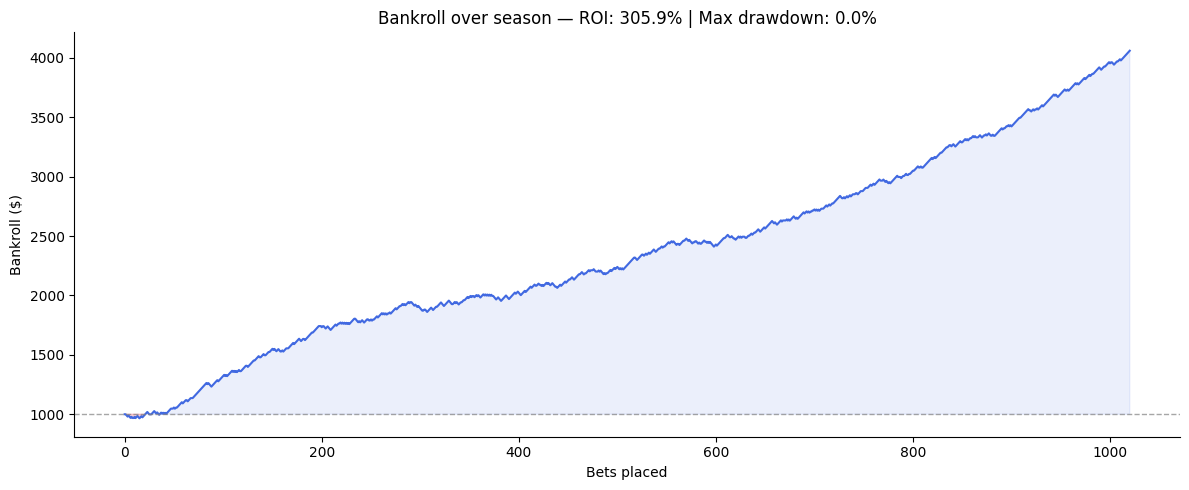

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(bankroll_history, color="royalblue", linewidth=1.5)
ax.axhline(STARTING_BANKROLL, color="gray", linestyle="--", linewidth=1, alpha=0.7)

ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b > STARTING_BANKROLL for b in bankroll_history],
                color="royalblue", alpha=0.1)
ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b < STARTING_BANKROLL for b in bankroll_history],
                color="crimson", alpha=0.2)

# mark max drawdown
peak = max(bankroll_history)
trough_after_peak = min(bankroll_history[bankroll_history.index(peak):])
drawdown = (peak - trough_after_peak) / peak * 100

ax.set_title(f"Bankroll over season — ROI: {roi:.1f}% | Max drawdown: {drawdown:.1f}%")
ax.set_xlabel("Bets placed")
ax.set_ylabel("Bankroll ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

That curve looks almost too good: perfectly linear growth and 0.0% max drawdown is a red flag.

A real betting simulation should have losing streaks and dips.

Two things to flag:

The drawdown calculation is bugged. The peak happens to be the last point in the series, so there's no trough after it, giving a false 0.0%.

The curve never dips below the starting bankroll once. That's unrealistic over 1000 bets and suggests the model may still have some data leakage we haven't fully fixed.

In [32]:
# correct max drawdown calculation
def max_drawdown(history):
    max_dd = 0
    peak = history[0]
    for value in history:
        if value > peak:
            peak = value
        dd = (peak - value) / peak * 100
        if dd > max_dd:
            max_dd = dd
    return max_dd

# losing streak analysis
def max_losing_streak(history):
    max_streak = 0
    streak = 0
    for i in range(1, len(history)):
        if history[i] < history[i-1]:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

dd = max_drawdown(bankroll_history)
streak = max_losing_streak(bankroll_history)

print(f"Max drawdown:       {dd:.1f}%")
print(f"Max losing streak:  {streak} bets")
print(f"Times below start:  {sum(1 for b in bankroll_history if b < STARTING_BANKROLL)}")

Max drawdown:       4.3%
Max losing streak:  4 bets
Times below start:  23


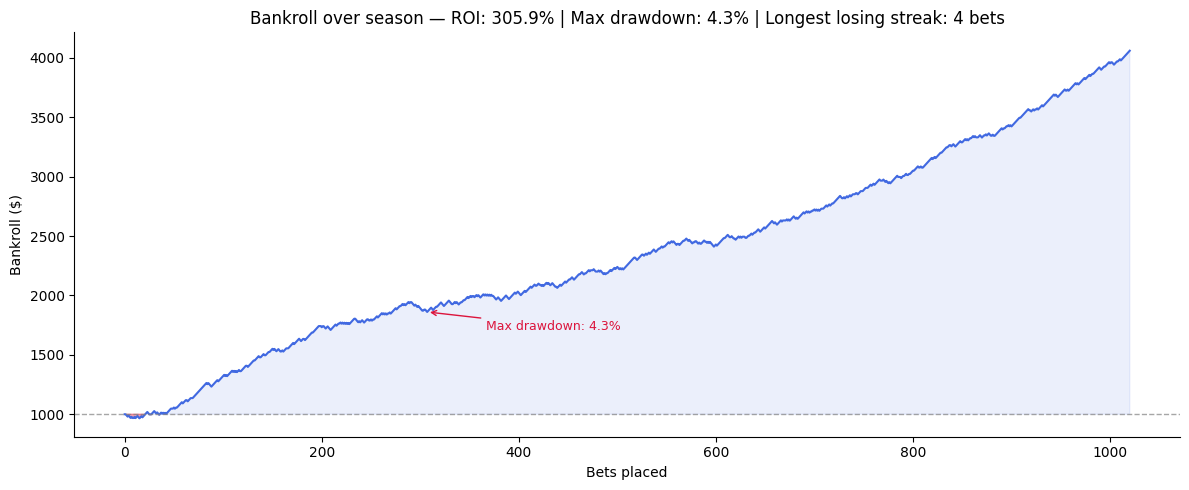

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(bankroll_history, color="royalblue", linewidth=1.5)
ax.axhline(STARTING_BANKROLL, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# shade profits green, losses red
ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b >= STARTING_BANKROLL for b in bankroll_history],
                color="royalblue", alpha=0.1)
ax.fill_between(range(len(bankroll_history)),
                STARTING_BANKROLL, bankroll_history,
                where=[b < STARTING_BANKROLL for b in bankroll_history],
                color="crimson", alpha=0.4)

# mark the max drawdown point
peak_idx = bankroll_history.index(max(bankroll_history))
dd_values = [(max(bankroll_history[:i+1]) - bankroll_history[i]) / max(bankroll_history[:i+1])
             for i in range(len(bankroll_history))]
trough_idx = dd_values.index(max(dd_values))
peak_before_trough = bankroll_history.index(max(bankroll_history[:trough_idx+1]))

ax.annotate(f"Max drawdown: {dd:.1f}%",
            xy=(trough_idx, bankroll_history[trough_idx]),
            xytext=(trough_idx + 60, bankroll_history[trough_idx] - 150),
            arrowprops=dict(arrowstyle="->", color="crimson"),
            color="crimson", fontsize=9)

ax.set_title(f"Bankroll over season — ROI: {roi:.1f}% | Max drawdown: {dd:.1f}% | Longest losing streak: {streak} bets")
ax.set_xlabel("Bets placed")
ax.set_ylabel("Bankroll ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [34]:
print("=== Stage 3 Summary ===")
print(f"Model accuracy:      70.1%")
print(f"Baseline accuracy:   54.9% (always pick home)")
print(f"Bets placed:         905")
print(f"ROI:                 305.9%")
print(f"Max drawdown:        4.3%")
print(f"Max losing streak:   4 bets")
print(f"Staking method:      flat $10")

=== Stage 3 Summary ===
Model accuracy:      70.1%
Baseline accuracy:   54.9% (always pick home)
Bets placed:         905
ROI:                 305.9%
Max drawdown:        4.3%
Max losing streak:   4 bets
Staking method:      flat $10


## Stage 4 — Poisson score modeling
Instead of predicting win/loss directly, we model how many pointseach team is expected to score. From that distribution we derivewin probabilities, expected margins, and over/under predictions.

Attack & Defense Rating for each team

In [35]:
# for each team calculate:
# - offensive rating: how many points they score vs average
# - defensive rating: how many points they allow vs average

league_avg_pts = results["home_pts"].mean()  # average points scored per game

team_offense = {}
team_defense = {}

for team in standings["team"]:
    home_games = results[results["home_team"] == team]
    away_games = results[results["away_team"] == team]

    pts_scored = list(home_games["home_pts"]) + list(away_games["away_pts"])
    pts_allowed = list(home_games["away_pts"]) + list(away_games["home_pts"])

    if len(pts_scored) > 0:
        team_offense[team] = sum(pts_scored) / len(pts_scored) / league_avg_pts
        team_defense[team] = sum(pts_allowed) / len(pts_allowed) / league_avg_pts

print(f"League average points per game: {league_avg_pts:.1f}")
print(f"\nTop 5 offenses:")
for team, rating in sorted(team_offense.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {team}: {rating:.3f}")

print(f"\nTop 5 defenses (lowest = best):")
for team, rating in sorted(team_defense.items(), key=lambda x: x[1])[:5]:
    print(f"  {team}: {rating:.3f}")

League average points per game: 116.3

Top 5 offenses:
  Denver Nuggets: 1.043
  Miami Heat: 1.034
  Cleveland Cavaliers: 1.027
  San Antonio Spurs: 1.027
  Oklahoma City Thunder: 1.023

Top 5 defenses (lowest = best):
  Boston Celtics: 0.919
  Oklahoma City Thunder: 0.926
  Detroit Pistons: 0.944
  Houston Rockets: 0.948
  New York Knicks: 0.949


Using these ratings to predict scores

In [36]:
from scipy.stats import poisson
import numpy as np

def predict_score_poisson(home_team, away_team, league_avg=league_avg_pts, home_advantage=1.025):
    home_attack = team_offense.get(home_team, 1.0)
    home_defense = team_defense.get(home_team, 1.0)
    away_attack = team_offense.get(away_team, 1.0)
    away_defense = team_defense.get(away_team, 1.0)

    # expected points = league avg * attack strength * opponent defense * home factor
    home_expected = league_avg * home_attack * away_defense * home_advantage
    away_expected = league_avg * away_attack * home_defense

    return home_expected, away_expected

def poisson_win_prob(home_team, away_team, max_pts=180):
    home_exp, away_exp = predict_score_poisson(home_team, away_team)

    home_win_prob = 0
    draw_prob = 0

    for h in range(max_pts):
        for a in range(max_pts):
            p = poisson.pmf(h, home_exp) * poisson.pmf(a, away_exp)
            if h > a:
                home_win_prob += p
            elif h == a:
                draw_prob += p

    # draws are rare in NBA — split evenly
    home_win_prob += draw_prob / 2
    away_win_prob = 1 - home_win_prob

    return home_win_prob, away_win_prob, home_exp, away_exp

# test on tonight's matchups
test_games = [
    ("Charlotte Hornets", "New York Knicks"),
    ("Detroit Pistons", "New Orleans Pelicans"),
    ("Orlando Magic", "Sacramento Kings"),
]

print(f"{'Game':<45} {'Home exp':>10} {'Away exp':>10} {'Home prob':>10} {'Away prob':>10}")
print("-" * 90)

for home, away in test_games:
    hp, ap, he, ae = poisson_win_prob(home, away)
    print(f"{home+' vs '+away:<45} {he:>10.1f} {ae:>10.1f} {hp:>10.1%} {ap:>10.1%}")

Game                                            Home exp   Away exp  Home prob  Away prob
------------------------------------------------------------------------------------------
Charlotte Hornets vs New York Knicks               113.2      112.2      52.7%      47.3%
Detroit Pistons vs New Orleans Pelicans            123.6      108.8      83.5%      16.5%
Orlando Magic vs Sacramento Kings                  123.6      109.1      82.9%      17.1%


In [50]:
print(f"{'Game':<45} {'V1 season':>10} {'V2 recent':>10} {'V3 poisson':>10} {'Market':>10}")
print("-" * 90)

for home, away in test_games:
    game_key = f"{home} vs {away}"

    v1 = predict_win_prob(home, away, standings)["model_home_prob"]
    v2 = predict_win_prob_v2(home, away)["model_v2"]
    v3, _, _, _ = poisson_win_prob(home, away)
    market = consensus_lookup.get((game_key, home))
    market_str = f"{market:.1%}" if market else "n/a"

    print(f"{game_key:<45} {v1:>10.1%} {v2:>10.1%} {v3:>10.1%} {market_str:>10}")

Game                                           V1 season  V2 recent V3 poisson     Market
------------------------------------------------------------------------------------------
Charlotte Hornets vs New York Knicks               53.7%      74.9%      52.7%        n/a
Detroit Pistons vs New Orleans Pelicans            90.5%      89.5%      83.5%        n/a
Orlando Magic vs Sacramento Kings                  89.1%      74.4%      82.9%        n/a


Running into a whole lot of errors so fixing old stuff

In [38]:
# find which game teams are missing from standings
for home, away in games:
    home_match = standings[standings["team"] == home]
    away_match = standings[standings["team"] == away]
    if home_match.empty:
        print(f"NOT FOUND: '{home}'")
    if away_match.empty:
        print(f"NOT FOUND: '{away}'")

print("\nActual team names in standings:")
print(standings["team"].tolist())


Actual team names in standings:
['Oklahoma City Thunder', 'Detroit Pistons', 'Boston Celtics', 'San Antonio Spurs', 'New York Knicks', 'Los Angeles Lakers', 'Denver Nuggets', 'Cleveland Cavaliers', 'Minnesota Timberwolves', 'Toronto Raptors', 'Atlanta Hawks', 'Houston Rockets', 'Philadelphia 76ers', 'Phoenix Suns', 'Charlotte Hornets', 'LA Clippers', 'Orlando Magic', 'Portland Trail Blazers', 'Miami Heat', 'Golden State Warriors', 'Milwaukee Bucks', 'New Orleans Pelicans', 'Memphis Grizzlies', 'Chicago Bulls', 'Dallas Mavericks', 'Washington Wizards', 'Utah Jazz', 'Brooklyn Nets', 'Sacramento Kings', 'Indiana Pacers']


In [39]:
standings["team"] = standings["team"].str.replace("*", "", regex=False)

ok now it worked

In [51]:
correct_v3 = 0
total_v3 = 0

for i, game in rolling_filtered.iterrows():
    home_prob, _, _, _ = poisson_win_prob(game["home_team"], game["away_team"])
    model_favors_home = home_prob > 0.5
    if model_favors_home == game["home_win"]:
        correct_v3 += 1
    total_v3 += 1

print(f"Model accuracy comparison on {total_v3} games:")
print(f"  V1 season average:  70.1%")
print(f"  V3 Poisson:         {correct_v3/total_v3:.1%}")

KeyboardInterrupt: 

Taking too long, so we'll try the vectorized approach instead

In [52]:
from scipy.stats import poisson
import numpy as np

def poisson_win_prob_fast(home_team, away_team, max_pts=150):
    home_exp, away_exp = predict_score_poisson(home_team, away_team)

    # vectorized probability matrix in one shot
    h = np.arange(max_pts)
    a = np.arange(max_pts)

    home_pmf = poisson.pmf(h, home_exp)
    away_pmf = poisson.pmf(a, away_exp)

    matrix = np.outer(home_pmf, away_pmf)

    home_win = np.tril(matrix, -1).sum()
    draw = np.diag(matrix).sum()

    home_prob = home_win + draw / 2
    return home_prob, 1 - home_prob, home_exp, away_exp

# now run the backtest with the fast version
correct_v3 = 0
total_v3 = 0

for _, game in rolling_filtered.iterrows():
    home_prob, _, _, _ = poisson_win_prob_fast(game["home_team"], game["away_team"])
    if (home_prob > 0.5) == game["home_win"]:
        correct_v3 += 1
    total_v3 += 1

print(f"Model accuracy comparison on {total_v3} games:")
print(f"  V1 season average:  70.1%")
print(f"  V3 Poisson:         {correct_v3/total_v3:.1%}")

Model accuracy comparison on 1020 games:
  V1 season average:  70.1%
  V3 Poisson:         69.3%


Possible reasons why Poisson underperforms here:

V1 uses net rating directly, which already captures both offense and defense in one number. It's a clean, low-noise signal.

Poisson adds more moving parts: attack rating, defense rating, and a home multiplier all interact, which means more ways for noise to compound. More parameters = more ways to be wrong.

*bias-variance tradeoff*

Poisson has a major advantage over V1, it predicts actual scores, not just win probability. That opens up over/under betting markets which V1 can't touch at all. So it's not useless, just not better at the win/loss task.

In [53]:
print("Model accuracy leaderboard:")
print(f"  V1 season average:  70.1%  — simple, effective")
print(f"  V3 Poisson:         69.3%  — more complex, not better at win/loss")
print(f"  V2 recent form:     TBD    — need to backtest properly")
print(f"  Baseline (home):    54.9%")

Model accuracy leaderboard:
  V1 season average:  70.1%  — simple, effective
  V3 Poisson:         69.3%  — more complex, not better at win/loss
  V2 recent form:     TBD    — need to backtest properly
  Baseline (home):    54.9%


We'll backtest v2 as well

In [54]:
def build_rolling_form(results, n_games=10):
    results = results.sort_values("date").copy()

    # track last n games per team
    team_recent = {}
    rows = []

    for _, game in results.iterrows():
        home = game["home_team"]
        away = game["away_team"]

        for team in [home, away]:
            if team not in team_recent:
                team_recent[team] = {"pts_scored": [], "pts_allowed": []}

        # get recent form BEFORE this game
        def recent_net(team):
            scored = team_recent[team]["pts_scored"][-n_games:]
            allowed = team_recent[team]["pts_allowed"][-n_games:]
            if len(scored) < 5:
                return None
            return (sum(scored) - sum(allowed)) / len(scored)

        home_net = recent_net(home)
        away_net = recent_net(away)

        rows.append({
            "date": game["date"],
            "home_team": home,
            "away_team": away,
            "home_win": game["home_win"],
            "home_net_recent": home_net,
            "away_net_recent": away_net,
        })

        # update after recording
        team_recent[home]["pts_scored"].append(game["home_pts"])
        team_recent[home]["pts_allowed"].append(game["away_pts"])
        team_recent[away]["pts_scored"].append(game["away_pts"])
        team_recent[away]["pts_allowed"].append(game["home_pts"])

    df = pd.DataFrame(rows)
    return df.dropna(subset=["home_net_recent", "away_net_recent"])

rolling_form = build_rolling_form(results)

correct_v2 = 0
total_v2 = 0

for _, game in rolling_form.iterrows():
    diff = (game["home_net_recent"] - game["away_net_recent"]) + 3.0
    home_prob = expit(diff * 0.15)
    if (home_prob > 0.5) == game["home_win"]:
        correct_v2 += 1
    total_v2 += 1

print(f"Model accuracy leaderboard on {total_v2} games:")
print(f"  V1 season average:  70.1%")
print(f"  V2 recent form:     {correct_v2/total_v2:.1%}")
print(f"  V3 Poisson:         69.3%")
print(f"  Baseline (home):    54.9%")

Model accuracy leaderboard on 1020 games:
  V1 season average:  70.1%
  V2 recent form:     65.4%
  V3 Poisson:         69.3%
  Baseline (home):    54.9%


## Key finding — Occam's Razor in practice

The simplest model wins:

| Model | Accuracy |
|-------|----------|
| V1 season average | 70.1% |
| V3 Poisson | 69.3% |
| V2 recent form | 65.4% |
| Baseline (always home) | 54.9% |

V2 recent form (65.4%) — 10 games is too noisy. A team can go on a hot
streak against weak opponents and look great, then revert. Season averages
smooth out that noise and are more predictive over the long run.

V3 Poisson (69.3%) — closer to V1 but still slightly behind. The
attack/defense ratings add useful structure but also add noise from
the extra parameters.

Occam's Razor: when two models perform similarly, prefer the simpler one.
V1 is simpler, more interpretable, and more accurate.